In [1]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import lmfit
from lmfit import minimize, Parameters
from astropy.io import fits

import uncertainties.umath as uum
from uncertainties import ufloat
from uncertainties import unumpy

import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

from magE.directMethod import directT, run_all
from magE.functions import mergeSpec, gaussian
from magE.plotutils import * 
from magE.constutils import *

PATH = '/home/benjamin/Documents/analogs/specs/final_spec/'
os.chdir(PATH)
os.getcwd()

'/home/benjamin/Documents/analogs/specs/final_spec'

In [2]:
z = []
for index in np.argsort(z_BN):
    z.append(z_BN[index])
    
z.pop(-2)

0.17754

In [3]:
np.median(z_BN)

0.07203

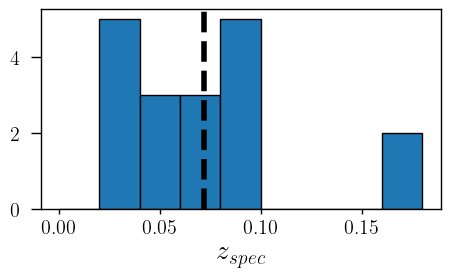

In [4]:
texPlot('on')
fig = plt.figure(figsize=(8, 4))
ax = fig.add_axes([0., 0., 0.5, 0.5])
ax.hist(z_BN, bins=np.arange(0, 0.2, 0.02), edgecolor='black')
ax.axvline(np.median(z_BN),ls='--', color='black', lw=4)
ax.set_xlabel(r'$z_{spec}$')
fig.savefig('/home/benjamin/Documents/analogs/redshift_dist.jpg',
           facecolor='white', bbox_inches='tight')

In [5]:
# read the data
import pandas as pd

j0021 = pd.read_csv('J0021' + '.csv')
j0023 = pd.read_csv('J0023' + '.csv')
j0136 = pd.read_csv('J0136' + '.csv')
j0240 = pd.read_csv('J0240' + '.csv')
j0252 = pd.read_csv('J0252' + '.csv')
j0305 = pd.read_csv('J0305' + '.csv')
j0950 = pd.read_csv('J0950' + '.csv')
j1146 = pd.read_csv('J1146' + '.csv')
j1226 = pd.read_csv('J1226' + '.csv')
j1444 = pd.read_csv('J1444' + '.csv')
j1448 = pd.read_csv('J1448' + '.csv')
j1624 = pd.read_csv('J1624' + '.csv')
j2101 = pd.read_csv('J2101' + '.csv')
j2119 = pd.read_csv('J2119' + '.csv')
j2212 = pd.read_csv('J2212' + '.csv')
j2215 = pd.read_csv('J2215' + '.csv')
j2225 = pd.read_csv('J2225' + '.csv')
j2337 = pd.read_csv('J2337' + '.csv')


mask_j0021 = (j0021['wave'] > 4780) * (j0021['wave'] < 4805)
mask_j0023 = (j0023['wave'] > 4580) * (j0023['wave'] < 4610)
mask_j0136 = (j0136['wave'] > 4610) * (j0136['wave'] < 4640)
mask_j0240 = (j0240['wave'] > 4705) * (j0240['wave'] < 4743)
mask_j0252 = (j0252['wave'] > 4470) * (j0252['wave'] < 4505)
mask_j0305 = (j0305['wave'] > 4725) * (j0305['wave'] < 4750)
mask_j0950 = (j0950['wave'] > 4780) * (j0950['wave'] < 4805)
mask_j1146 = (j1146['wave'] > 4600) * (j1146['wave'] < 4623)
mask_j1226 = (j1226['wave'] > 4760) * (j1226['wave'] < 4790)
mask_j1444 = (j1444['wave'] > 4520) * (j1444['wave'] < 4546)
mask_j1448 = (j1448['wave'] > 4470) * (j1448['wave'] < 4500)
mask_j1624 = (j1624['wave'] > 4490) * (j1624['wave'] < 4515)
mask_j2101 = (j2101['wave'] > 5210) * (j2101['wave'] < 5230)
mask_j2119 = (j2119['wave'] > 4505) * (j2119['wave'] < 4520)
mask_j2212 = (j2212['wave'] > 5125) * (j2212['wave'] < 5150)
mask_j2215 = (j2215['wave'] > 4690) * (j2215['wave'] < 4715)
mask_j2225 = (j2225['wave'] > 4645) * (j2225['wave'] < 4665)
mask_j2337 = (j2337['wave'] > 4670) * (j2337['wave'] < 4685)

gals = [
    j1448,
    j0252,
    j1624,
    j2119,
    j1444,
    j0023,
    j1146,
    j0136,
    j2225,
    j2337,
    j2215,
    j0240,
    j0305,
    j1226,
    j0950,
    j0021,
    j2212,
    j2101
]

masks = [
    mask_j1448,
    mask_j0252,
    mask_j1624,
    mask_j2119,
    mask_j1444,
    mask_j0023,
    mask_j1146,
    mask_j0136,
    mask_j2225,
    mask_j2337,
    mask_j2215,
    mask_j0240,
    mask_j0305,
    mask_j1226,
    mask_j0950,
    mask_j0021,
    mask_j2212,
    mask_j2101
]


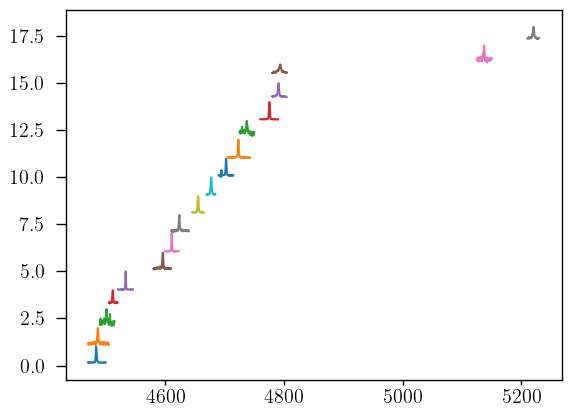

In [6]:

for i in range(len(z)):
    plt.plot(gals[i]['wave'][masks[i]], i + (gals[i]['flux'][masks[i]]/np.max(gals[i]['flux'][masks[i]])))

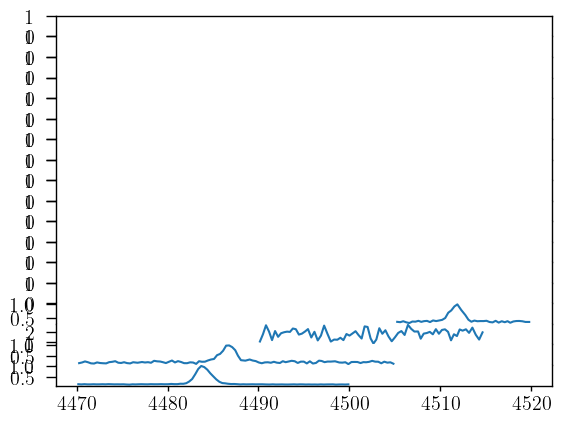

In [7]:
fig, axs = plt.subplots(nrows=18, ncols=1, sharex=True)
fig.subplots_adjust(hspace=0.)

for i in range(0, 17):
    axs[i].spines['bottom'].set_visible(False)
for i in range(1, 18):
    axs[i].spines['top'].set_visible(False)

axs[14].plot(j2119['wave'][mask_j2119], j2119['flux'][mask_j2119]/np.max(j2119['flux'][mask_j2119]))
axs[15].plot(j1624['wave'][mask_j1624], j0252['flux'][mask_j1624]/np.max(j1624['flux'][mask_j1624]))
axs[16].plot(j0252['wave'][mask_j0252], j0252['flux'][mask_j0252]/np.max(j0252['flux'][mask_j0252]))
axs[17].plot(j1448['wave'][mask_j1448], j1448['flux'][mask_j1448]/np.max(j1448['flux'][mask_j1448]))

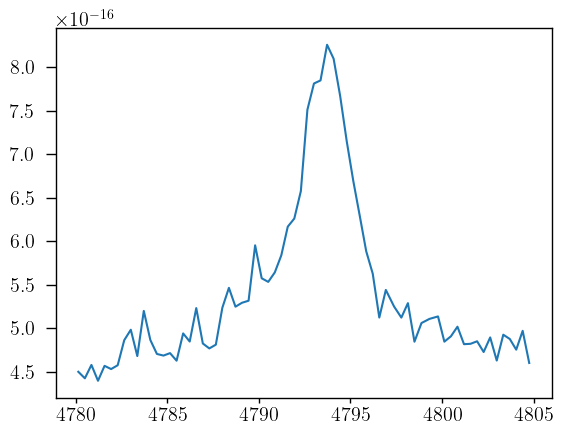

In [8]:

plt.plot(j0021['wave'][mask_j0021], j0021['flux'][mask_j0021])

Text(3986.8542400000006, 1.2, '[OII]')

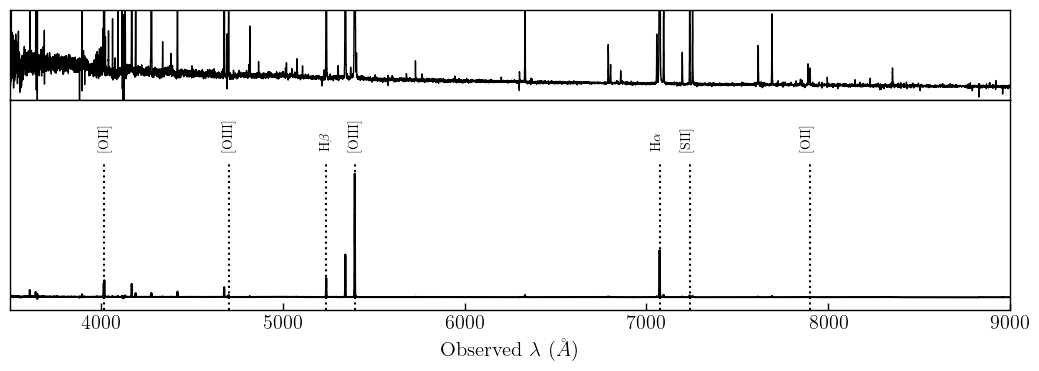

In [9]:
fig = plt.figure()
fig.set_size_inches((10, 3))

ax_up = fig.add_axes([0., 0.7, 1, 0.3])
ax_down = fig.add_axes([0., 0., 1, 0.7])

ax_up.step(j2215['wave'], j2215['flux'] / np.max(j2215['flux']),
           where='mid', lw=1, color='black')
ax_up.set_xlim(3500, 9000)
ax_up.set_ylim(-0.001,0.01)
ax_up.set_xticks([])
ax_up.set_yticks([])

ax_down.step(j2215['wave'], j2215['flux'] / np.max(j2215['flux']),
            color='black')
ax_down.set_xlim(3500, 9000)
ax_down.set_ylim(-0.1, 1.6)
ax_down.set_yticks([])
ax_down.tick_params(axis='x', direction='in', length=5)
ax_down.set_xlabel(r'Observed $\lambda$ ($\AA$)', fontsize=15)


ax_down.axvline(wave_cat['[OII]7330'] * (1 + 0.07775), ls=':', ymax=0.7)
ax_down.axvline(wave_cat['[SII]6716'] * (1 + 0.07775), ls=':', ymax=0.7)
ax_down.axvline(wave_cat['Ha'] * (1 + 0.07775), ls=':', ymax=0.7)
ax_down.axvline(wave_cat['Hb'] * (1 + 0.07775), ls=':', ymax=0.7)
ax_down.axvline(wave_cat['[OIII]5007'] * (1 + 0.07775), ls=':', ymax=0.7)
ax_down.axvline(wave_cat['[OIII]4363'] * (1 + 0.07775), ls=':', ymax=0.7)
ax_down.axvline(wave_cat['[OII]3726'] * (1 + 0.07775), ls=':', ymax=0.7)


ax_down.text(s=r'[OII]', x= wave_cat['[OII]7330'] * (1 + 0.07), y=1.2, rotation=90)
ax_down.text(s=r'[SII]', x= wave_cat['[SII]6716'] * (1 + 0.07), y=1.2, rotation=90)
ax_down.text(s=r'H$\alpha$', x= wave_cat['Ha'] * (1 + 0.07), y=1.2, rotation=90)
ax_down.text(s=r'H$\beta$', x= wave_cat['Hb'] * (1 + 0.07), y=1.2, rotation=90)
ax_down.text(s=r'[OIII]', x= wave_cat['[OIII]5007'] * (1 + 0.07), y=1.2, rotation=90)
ax_down.text(s=r'[OIII]', x= wave_cat['[OIII]4363'] * (1 + 0.07), y=1.2, rotation=90)
ax_down.text(s=r'[OII]', x= wave_cat['[OII]3726'] * (1 + 0.07), y=1.2, rotation=90)

#fig.savefig('/home/benjamin/Documents/analogs/sample_spec.jpg', bbox_inches='tight', facecolor='white')

(7000.0, 8000.0)

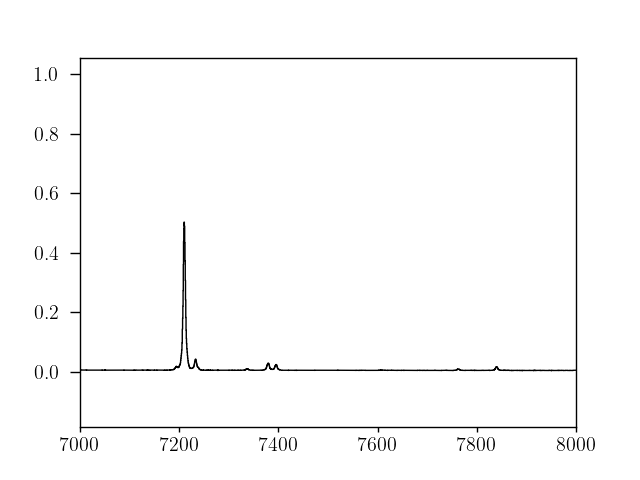

In [10]:
%matplotlib widget
plt.step(j0021['wave'], j0021['flux'] / np.max(j0021['flux']),
           where='mid', lw=1, color='black')
plt.xlim(7000, 8000)